In [35]:
is_local = False

try:
    # 1. Mount Google Drive
    from google.colab import drive

    drive.mount('/content/drive')
except:
    print("Running locally")
    is_local = True

Running locally


In [36]:
if is_local:
    # Allowing dynamic links, hot-reload, to our custom modules
    %load_ext autoreload
    %autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [37]:
if not is_local:
    # 2. Change the current working directory to the sandbox folder
    import os

    # Update this path if you placed the folder somewhere else in your Drive
    repo_path = '/content/drive/MyDrive/dl-gen-lyrics'
    sandbox_path = os.path.join(repo_path, 'sandbox')
    os.chdir(sandbox_path)
    print("Current Working Directory:", os.getcwd())

    # 3. Add the 'src' directory to the Python path so local imports work
    import sys

    src_path = os.path.abspath(os.path.join(repo_path, 'src'))
    if src_path not in sys.path:
        sys.path.append(src_path)

In [38]:
if not is_local:
    # 4. Install requirements (optional but recommended)
    # !pip install -r ../requirements.txt
    !pip install -q contractions>=0.1.73
    !pip install -q bert-score>=0.3.13
    !pip install mauve-text>=0.3.0
    !pip install json5

In [39]:
import os, re, sys, traceback, csv

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sentencepiece as spm

from tqdm import tqdm
from sklearn.feature_extraction.text import TfidfVectorizer

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data

os.getcwd()

'C:\\Beryllium Base\\WORKSPACES\\MTECH\\dl-gen-lyrics\\sandbox'

In [40]:
import generator_core as core
from aspect_midnight import Word2Vec_SkipGram, ArrayToDatasetForW2V
from aspect_tetra import *
from aspect_cobalt import Cobalt
from dl_trainer import Trainer


In [41]:
try:
    ds_subset = pd.read_csv(os.path.join('temp', 'genius_lyrics_subset.csv'))
    display(ds_subset.head())
except:
    traceback.print_exc()

,Unnamed: 0,title,tag,artist,year,lyrics,id,language
0,123725,In Memory of W. B. Yeats,misc,W. H. Auden,2013,I\n\nHe disappeared in the dead of winter:\nTh...,134446,en
1,2614099,Sthlm City,pop,Rebecca & Fiona,2018,"[Intro]\nI mean, like, it's okay\nOne day, you...",3931557,en
2,2550228,Fallin 2010,pop,Mozhdah,2010,[Verse 1]\nCan you take it easy\nWhile I make ...,3840000,en
3,3539706,Can the Circle Be Unbroken,country,Johnny Cash,1982,I was standing by the window\nOn one cold and ...,5350667,en
4,2650114,Marijuana,pop,Jah Cure,2019,[Intro: Jah Cure]\nOne puff one draw\nFrees th...,3982786,en


In [42]:
try:
    cobalt = Cobalt(ds_subset)
except:
    traceback.print_exc()

Loaded Cache for Midnight._prepare_ds_data.cached
Loaded Cache for Midnight._get_custom_tokens.cached
Loaded Cache for Midnight._get_genre_dict.cached
Loaded Cache for Midnight._prepare_tfidf.cached
Loaded Cache for Midnight._prepare_vocabulary temp\lyrics_sp.model
Loaded Cache for Midnight._prepare_embedder.cached


C:\Beryllium Base\WORKSPACES\MTECH\dl-gen-lyrics\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Beryllium Base\WORKSPACES\MTECH\dl-gen-lyrics\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Loaded Cache for Cobalt._prepare_training_data.cached
Loaded Cache for Cobalt._prepare_language_model.cached


In [43]:
try:
    print(cobalt.training_data.head())
except:
    traceback.print_exc()

0    [17, 2660, 68, 15, 2855, 26, 902, 16, 17, 1796...
1    [17, 2660, 68, 15, 1951, 1119, 16, 17, 1796, 1...
2    [17, 2660, 68, 15, 1951, 1119, 16, 17, 1796, 1...
3    [17, 2660, 68, 15, 7403, 297, 5743, 16, 17, 17...
4    [17, 2660, 68, 15, 1951, 1119, 16, 17, 1796, 1...
Name: tag, dtype: object


In [44]:
try:
    # print(cobalt.language_model.trainer.display_metrics)
    cobalt.language_model.trainer = Trainer(
        model=cobalt.language_model,
        train_dataloader=cobalt.language_model.trainer.train_dataloader,
        criterion=nn.CrossEntropyLoss(ignore_index=0, label_smoothing=0.1),
        optimizer=cobalt._optimizer,
        epochs=1,
        device='cpu',
        record_per_batch_training_loss=True,
        model_train_step=cobalt._model_train_step,
        model_criteria_step=cobalt._model_criteria_step,
        checkpoint_frequency_batch=50,
        # on_batch_callback=cobalt.cache_checkpoint_callback,
        # on_batch_callback_frequency=50,
        display_metrics=cobalt.display_metrics
    )
except:
    traceback.print_exc()

In [45]:
# try:
#     print(cobalt.detokenize_ids(cobalt.training_data.iloc[0]))
# except:
#     traceback.print_exc()

In [46]:
try:
    train_language_model = True
    print(cobalt.language_model)
except:
    traceback.print_exc()

BiGRULyricsModel(vocab=16000, embed=512, hidden=368, layers=4, params=17,650,512)


In [47]:
print("Language Model Parameters:", cobalt.get_language_model_parameter_count())
print("Embedder Parameters:", cobalt.get_embedder_parameter_count())

Language Model Parameters: 9458512
Embedder Parameters: 8192000


In [48]:
try:
    print(sum([x.numel() for x in cobalt.language_model.gru.parameters()]))
    print(sum([x.numel() for x in cobalt.language_model.output_proj.parameters()]))
    print(368 * 16000)
except:
    traceback.print_exc()

3417984
5904000
5888000


In [49]:
try:
    train_language_model = True
    print(cobalt.language_model.gru.bidirectional)
except:
    traceback.print_exc()

False


In [50]:
# Print the batch size used by the DataLoader
print("Batch Size:", cobalt.language_model.trainer.train_dataloader.batch_size)

# Print the sequence length used by the LyricsDataset
print("Sequence Length:", cobalt.language_model.trainer.train_dataloader.dataset.seq_len)

Batch Size: 32
Sequence Length: 1024


In [52]:
try:
    if train_language_model:
        cobalt.language_model.trainer.device = 'cuda'
        cobalt.language_model.trainer.epochs = 1

        for pg in cobalt.language_model.trainer.optimizer.param_groups:
            pg['lr'] = 0.00001
            print(pg['lr'])

        cobalt.language_model.embedding.weight.requires_grad = True
        print(cobalt.language_model.embedding.weight.requires_grad)

        cobalt.language_model.trainer.train_dataloader.dataset.seq_len = 128
        print(cobalt.language_model.trainer.train_dataloader.dataset.seq_len)

        cobalt.language_model.trainer.train_dataloader = data.DataLoader(
            cobalt.language_model.trainer.train_dataloader.dataset,
            batch_size=32,
            shuffle=False,
            collate_fn=cobalt.language_model.trainer.train_dataloader.collate_fn,
        )

except:
    traceback.print_exc()

1e-05
True
128


In [57]:
try:
    if train_language_model:
        cobalt.language_model.trainer.train()
except:
    traceback.print_exc()

Epoch:  0/ 1    Train Loss: 3.55    TTS: 1.06    ETA: 844.36    Bleu Score: 0.4385
Epoch:  0/ 1    Train Loss: 3.50    TTS: 2.11    ETA: 745.59    Bleu Score: 0.4405
Epoch:  0/ 1    Train Loss: 3.57    TTS: 3.11    ETA: 706.27    Bleu Score: 0.4395
Epoch:  0/ 1    Train Loss: 3.63    TTS: 4.14    ETA: 691.31    Bleu Score: 0.4281
Epoch:  0/ 1    Train Loss: 3.50    TTS: 5.17    ETA: 681.92    Bleu Score: 0.4368
Epoch:  0/ 1    Train Loss: 3.49    TTS: 6.21    ETA: 676.90    Bleu Score: 0.4288
Epoch:  0/ 1    Train Loss: 3.59    TTS: 7.03    ETA: 672.34    Bleu Score: 0.4304
Epoch:  0/ 1    Train Loss: 3.45    TTS: 8.05    ETA: 667.77    Bleu Score: 0.4461
Epoch:  0/ 1    Train Loss: 3.62    TTS: 9.05    ETA: 662.83    Bleu Score: 0.4232
Epoch:  0/ 1    Train Loss: 3.52    TTS: 10.07    ETA: 659.23    Bleu Score: 0.4382
Epoch:  0/ 1    Train Loss: 3.48    Agg. Loss: 3.52    TTS: 11.08    ETA: 656.15    Bleu Score: 0.4468
Epoch:  0/ 1    Train Loss: 3.32    Agg. Loss: 3.51    TTS: 12.11 

Traceback (most recent call last):
  File "C:\Users\mcxiv\AppData\Local\Temp\ipykernel_25864\170530448.py", line 3, in <module>
    cobalt.language_model.trainer.train()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "C:\Beryllium Base\WORKSPACES\MTECH\dl-gen-lyrics\src\dl_trainer\trainer.py", line 205, in train
    self._train_step(epoch)
    ~~~~~~~~~~~~~~~~^^^^^^^
  File "C:\Beryllium Base\WORKSPACES\MTECH\dl-gen-lyrics\src\dl_trainer\trainer.py", line 242, in _train_step
    display_metrics = self.display_metrics(self, locals())
  File "C:\Beryllium Base\WORKSPACES\MTECH\dl-gen-lyrics\.venv\Lib\site-packages\torch\utils\_contextlib.py", line 124, in decorate_context
    return func(*args, **kwargs)
  File "C:\Beryllium Base\WORKSPACES\MTECH\dl-gen-lyrics\.venv\Lib\site-packages\torch\utils\_contextlib.py", line 9, in display_metrics
    from collections.abc import Callable
    
KeyboardInterrupt


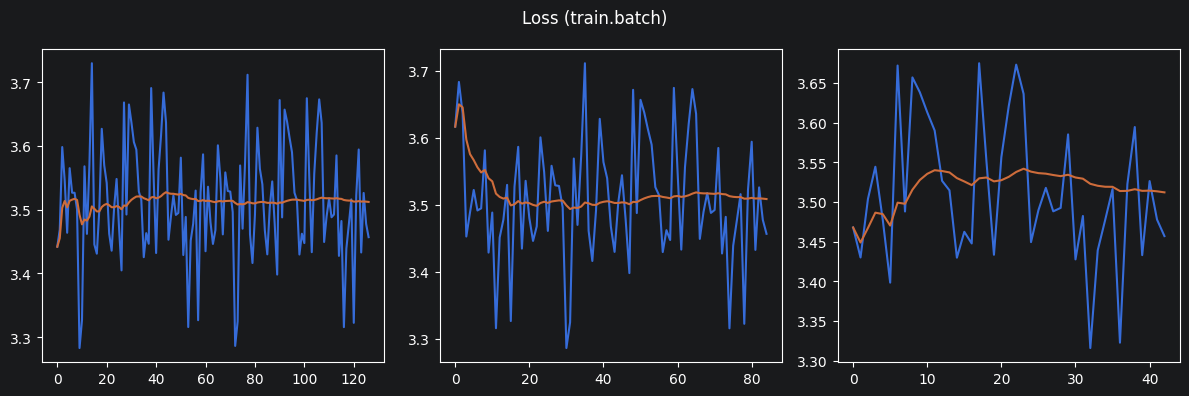

In [58]:
try:
    cobalt.language_model.trainer.plot_loss()
except:
    traceback.print_exc()

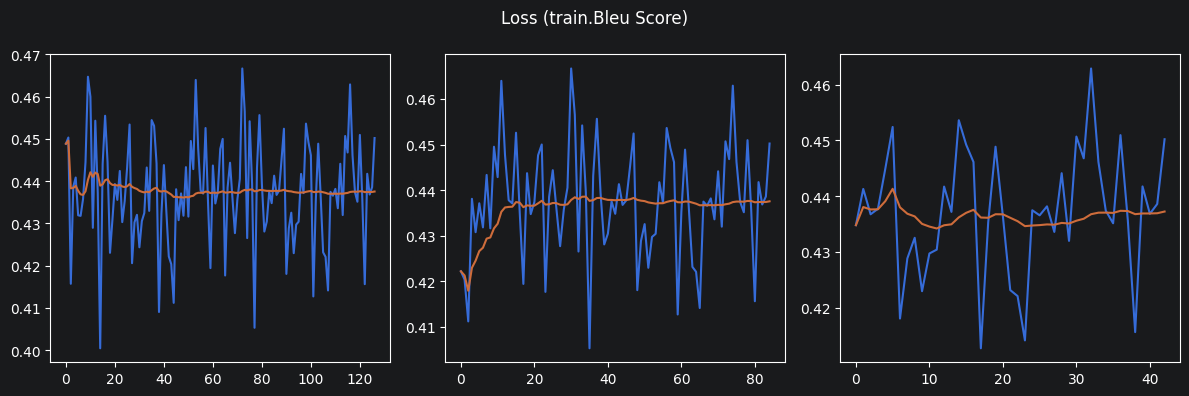

In [61]:
try:
    cobalt.language_model.trainer.plot_loss('train.Bleu Score')
except:
    traceback.print_exc()

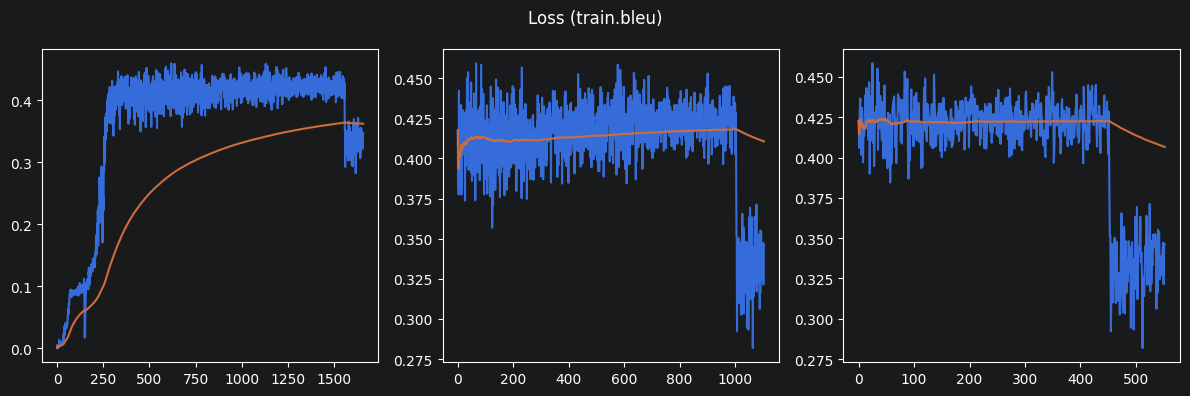

In [57]:
try:
    cobalt.language_model.trainer.plot_loss('train.bleu')
except:
    traceback.print_exc()

In [58]:
# try:
#     cobalt.language_model.trainer.load_model('batch_savepoint_BiGRULyricsModel.pt')
# except:
#     traceback.print_exc()

In [59]:
try:
    if train_language_model:
        rewrite_language_model_cache = True
        if rewrite_language_model_cache:
            flight = 'Cobalt._prepare_language_model.cached'
            for file in ['bone', 'pkl']:
                file = os.path.join('temp', f'{flight}.{file}')
                if os.path.exists(file): os.remove(file)
            core.key_cached('cached', lambda: cobalt.language_model, group='Cobalt._prepare_language_model')
            print("Saved")
except:
    traceback.print_exc()

Saved


In [60]:
try:
    _song = cobalt.inference('pop', ['black', 'enter', 'spell', 'priests', 'dragon'], max_len=400,
                             top_k=10,
                             temperature=1.0)
    print(cobalt.pollute_text(_song))
except:
    traceback.print_exc()

[ refrain
and you've be the mind
i've make the mind is in your love i got you like , oh
i've see

i got the life to be the world
you got

i're the way it'll make
you'm a life to be to
and the mind you can know
i got
i've see your way you know it's a " s
[ verse .
you " t be the mind ?
the way it's all my , i're ?
i've get the always be all , i can't be a mind
you got a little love , i don't be the , i ain't you the "
i've see it

i got a mind
but i "cause i got " yeah
but i don't , i got you
and i " re the love to be
you got you
but i don


In [61]:
try:
    if train_language_model:
        timers = cobalt.language_model.trainer.timer.timers
        for key in timers:
            print(key, timers[key].average)
except:
    traceback.print_exc()

train 0.0
_train_step 0.0
train_dataloader 0.0017753861779200323
batch 0.6832211763427596


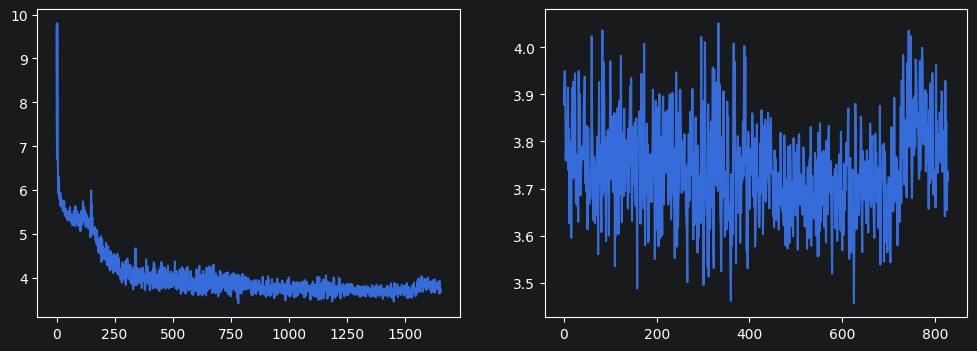

In [62]:
try:
    if train_language_model:
        loss = cobalt.language_model.trainer.loss
        fig, axs = plt.subplots(1, 2, figsize=(12, 4))
        axs[0].plot(loss['train.batch'])
        axs[1].plot(loss['train.batch'][int(0.5 * len(loss['train.batch'])):])
        plt.show()
except:
    traceback.print_exc()

In [18]:
# Assuming your Cobalt instance is called 'cobalt'
cobalt.generate_evaluation_samples(
    output_file="llm_evaluation_samples.txt",
    n_songs=10,
    max_len=400,  # Give it room to generate a decently sized song
    temperature=1.0  # Standard temperature for creative text generation
)

Generating song 1/10 [Genre: pop, Themes: ['o', 'lamb', 'come']]...


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:1415: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /pytorch/aten/src/ATen/native/cudnn/RNN.cpp:1480.)
  result = _VF.gru(


Generating song 2/10 [Genre: rb, Themes: ['let', "want's", 'gotta']]...
Generating song 3/10 [Genre: pop, Themes: ['ignored', 'distracted', 'clandestine']]...
Generating song 4/10 [Genre: misc, Themes: ['shelf', 'girl', 'type']]...
Generating song 5/10 [Genre: pop, Themes: ['midnight', 'medicine', 'remedy']]...
Generating song 6/10 [Genre: rap, Themes: ['gucci', 'paula', 'deen']]...
Generating song 7/10 [Genre: country, Themes: ['tree', 'apple', 'chapel']]...
Generating song 8/10 [Genre: pop, Themes: ['life', 'hard', 'housewife']]...
Generating song 9/10 [Genre: rap, Themes: ['ya', 'niggas', 'dog']]...
Generating song 10/10 [Genre: rock, Themes: ['won', 'loved', 'yesterday']]...
Successfully saved 10 songs to llm_evaluation_samples.txt


In [13]:
evaluator = SolutionEvaluator(cobalt)

In [14]:
evaluator.compute_perplexity(n_sample=100, batch_size=10)

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:1415: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /pytorch/aten/src/ATen/native/cudnn/RNN.cpp:1480.)
  result = _VF.gru(


np.float64(9.210328149795533)

In [16]:
evaluator.compute_self_bleu(n_sample=100, batch_size=10)

np.float64(0.08562993053939343)

In [18]:
evaluator.compute_bertscore(n_sample=100, batch_size=10)

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:1415: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /pytorch/aten/src/ATen/native/cudnn/RNN.cpp:1480.)
  result = _VF.gru(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


{'precision': np.float64(0.7441785931587219),
 'recall': np.float64(0.6477471351623535),
 'f1': np.float64(0.6915319085121154)}

In [19]:
evaluator.compute_mauve(n_sample=100, batch_size=10)

Featurizing p:   0%|          | 0/10 [00:00<?, ?it/s]

Featurizing q:   0%|          | 0/10 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:1415: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /pytorch/aten/src/ATen/native/cudnn/RNN.cpp:1480.)
  result = _VF.gru(


Featurizing p:   0%|          | 0/10 [00:00<?, ?it/s]

Featurizing q:   0%|          | 0/10 [00:00<?, ?it/s]

...

Featurizing q:   0%|          | 0/10 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:1415: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /pytorch/aten/src/ATen/native/cudnn/RNN.cpp:1480.)
  result = _VF.gru(


Featurizing p:   0%|          | 0/10 [00:00<?, ?it/s]

Featurizing q:   0%|          | 0/10 [00:00<?, ?it/s]

np.float64(0.5466917241570854)